In [3]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [4]:
from sklearn.preprocessing import label_binarize

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Conv1D,
    MaxPooling1D,
    Dense, Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

In [5]:
wfdb.dl_database('mitdb', dl_dir='mitdb')

record = wfdb.rdrecord('mitdb/100')
signal = record.p_signal[:, 0]

annotation = wfdb.rdann('mitdb/100', 'atr')

label_map = {
    'N':0,
    'A':1,
    'V':2,
    'L':3,
    'R':4
}

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [6]:
X, y = [], []

window_size = 200

for i in range(len(annotation.sample)):

    sym = annotation.symbol[i]

    if sym in label_map:

        start = annotation.sample[i] - window_size//2
        end = annotation.sample[i] + window_size//2

        if start > 0 and end < len(signal):

            X.append(signal[start:end])
            y.append(label_map[sym])

X = np.array(X)
y = np.array(y)

In [7]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

X = X.reshape(X.shape[0], X.shape[1], 1)

y_cat = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42
)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_ecg_model.h5",
    monitor="val_accuracy",
    save_best_only=True
)

In [11]:
lstm_model = Sequential([

    LSTM(64, return_sequences=True,
         input_shape=(X.shape[1],1)),

    Dropout(0.3),

    LSTM(32),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(y_cat.shape[1], activation='softmax')

])

lstm_model.compile(
    optimizer=RMSprop(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:
gru_model = Sequential([

    GRU(64, return_sequences=True,
        input_shape=(X.shape[1],1)),

    Dropout(0.3),

    GRU(32),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(y_cat.shape[1], activation='softmax')

])
gru_model.compile(
    optimizer=RMSprop(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [13]:
hybrid_model = Sequential([

    Conv1D(64, 3,
           activation='relu',
           input_shape=(X.shape[1],1)),

    BatchNormalization(),

    MaxPooling1D(2),

    Dropout(0.3),

    Conv1D(32, 3, activation='relu'),

    MaxPooling1D(2),

    Dropout(0.3),

    LSTM(64),

      Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(y_cat.shape[1], activation='softmax')

])

hybrid_model.compile(
    optimizer=RMSprop(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)
history_hybrid = hybrid_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9068 - loss: 0.4053

57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 185ms/step - accuracy: 0.9681 - loss: 0.1907 - val_accuracy: 0.9846 - val_loss: 0.0820
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.9851 - loss: 0.0840 - val_accuracy: 0.9846 - val_loss: 0.0816
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9851 - loss: 0.0872 - val_accuracy: 0.9846 - val_loss: 0.0800
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - accuracy: 0.9851 - loss: 0.0859 - val_accuracy: 0.9846 - val_loss: 0.0801
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.9851 - loss: 0.0857 - val_accuracy: 0.9846 - val_loss: 0.0802
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.9851 - loss: 0.0862 - val_accuracy: 0.9846 - val_loss: 0.0805
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.9851 - loss: 0.0863 - val_accuracy: 0.9846 - val_loss: 0.0827
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.9851 - loss: 0.0847 - val_accuracy: 0.9846

In [19]:
def evaluate(model, name):

    print("\n====================")
    print(name)
    print("====================")

    pred_prob = model.predict(X_test)

    pred = np.argmax(pred_prob, axis=1)
    true = np.argmax(y_test, axis=1)

    print(classification_report(true, pred))

    cm = confusion_matrix(true, pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    y_test_bin = label_binarize(true,
                                classes=[0,1,2,3,4])

    plt.figure(figsize=(6,5))

    for i in range(y_cat.shape[1]):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            pred_prob[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'Class {i} AUC={roc_auc:.2f}'
        )

    plt.plot([0,1], [0,1], 'k--')

    plt.title(name + " ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    plt.show()


LSTM MODEL
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       448
           1       0.00      0.00      0.00         7

    accuracy                           0.98       455
   macro avg       0.49      0.50      0.50       455
weighted avg       0.97      0.98      0.98       455



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


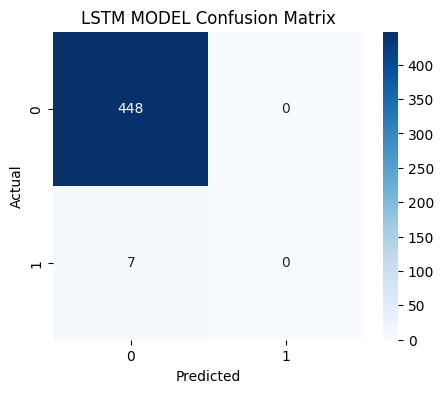

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


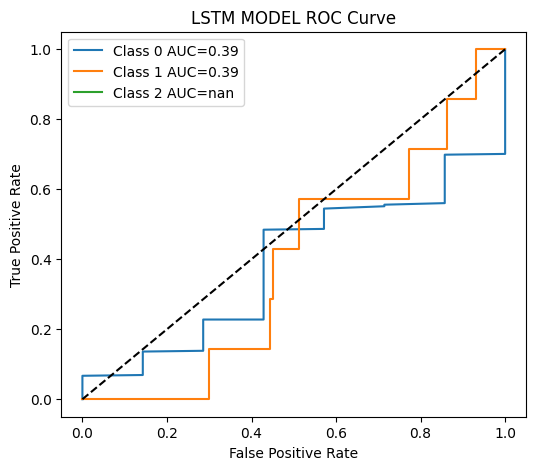


GRU MODEL
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       448
           1       0.00      0.00      0.00         7

    accuracy                           0.98       455
   macro avg       0.49      0.50      0.50       455
weighted avg       0.97      0.98      0.98       455



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


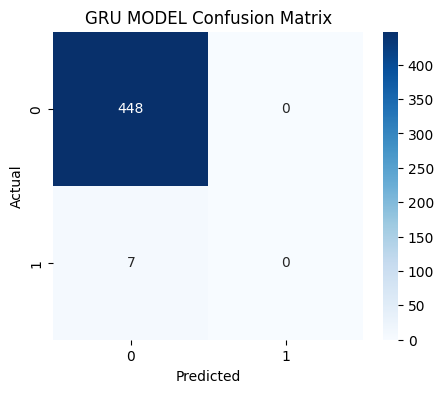

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


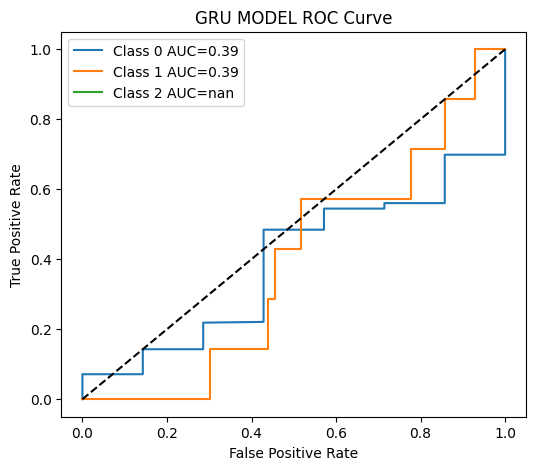


CNN + LSTM HYBRID
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       448
           1       0.00      0.00      0.00         7

    accuracy                           0.98       455
   macro avg       0.49      0.50      0.50       455
weighted avg       0.97      0.98      0.98       455



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


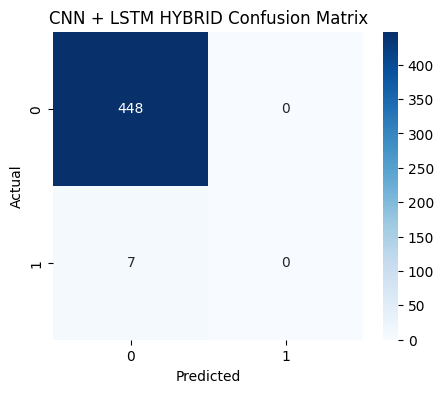

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


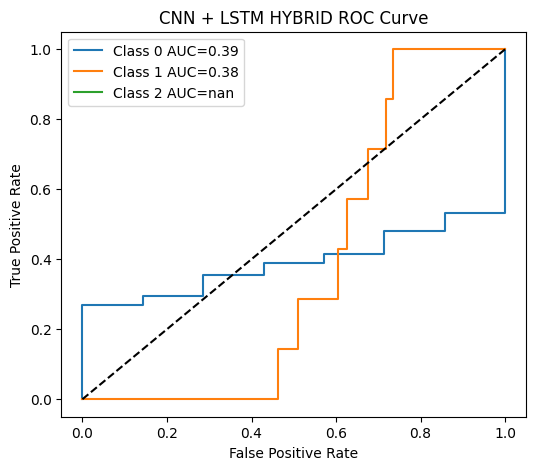

In [20]:
evaluate(lstm_model, "LSTM MODEL")

evaluate(gru_model, "GRU MODEL")

evaluate(hybrid_model, "CNN + LSTM HYBRID")

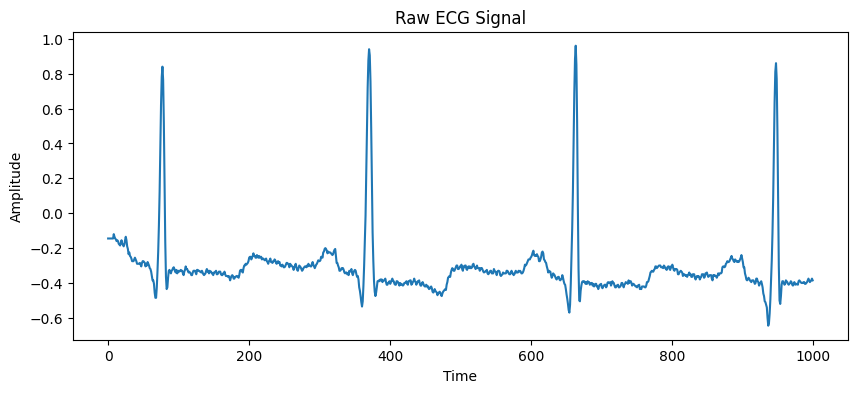

In [21]:
plt.figure(figsize=(10,4))

plt.plot(signal[:1000])

plt.title("Raw ECG Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

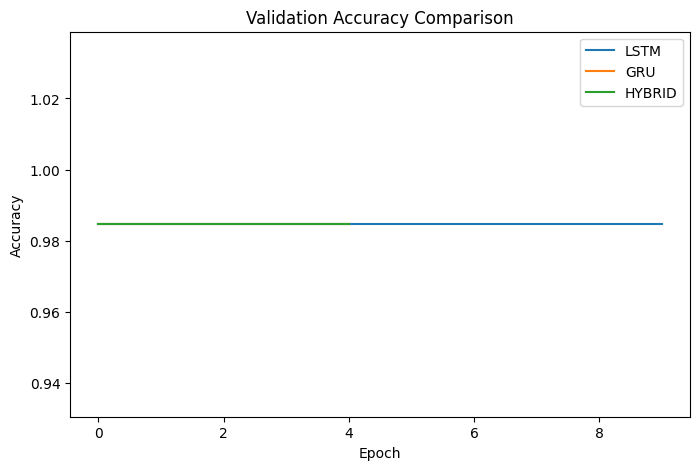

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history['val_accuracy'],
    label='LSTM'
)

plt.plot(
    history_gru.history['val_accuracy'],
    label='GRU'
)

plt.plot(
    history_hybrid.history['val_accuracy'],
    label='HYBRID'
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

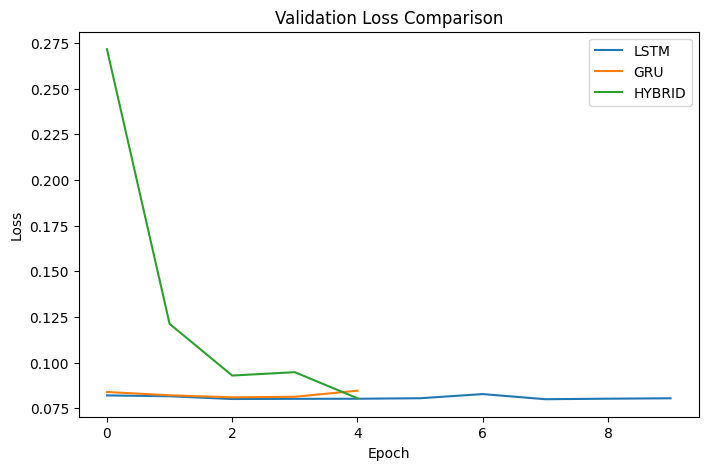

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history['val_loss'],
    label='LSTM'
)

plt.plot(
    history_gru.history['val_loss'],
    label='GRU'
)

plt.plot(
    history_hybrid.history['val_loss'],
    label='HYBRID'
)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

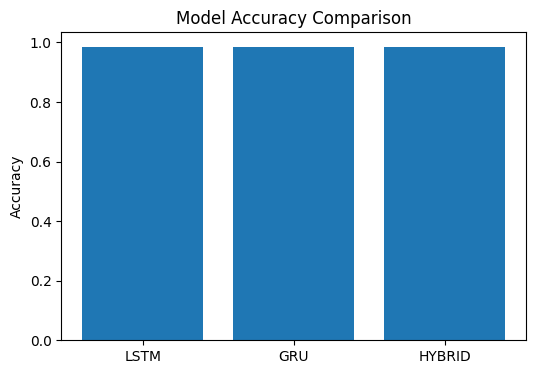

In [24]:
lstm_acc = max(history_lstm.history['val_accuracy'])
gru_acc = max(history_gru.history['val_accuracy'])
hybrid_acc = max(history_hybrid.history['val_accuracy'])

models = ['LSTM', 'GRU', 'HYBRID']
accuracy = [lstm_acc, gru_acc, hybrid_acc]

plt.figure(figsize=(6,4))

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
lstm_model.save("lstm_ecg.h5")

gru_model.save("gru_ecg.h5")

hybrid_model.save("hybrid_ecg.h5")

print("ALL MODELS SAVED SUCCESSFULLY 🚀")


: 